In [1]:
import pandas as pd

orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')

print(orders.shape, customers.shape, payments.shape)

(99441, 8) (99441, 5) (103886, 5)


In [2]:
# Merge orders with customers
df = orders.merge(customers, on='customer_id', how='left')

# Merge with payments
df = df.merge(payments, on='order_id', how='left')

# Check the combined shape and look at columns
print(df.shape)
df.head()

(103887, 16)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,credit_card,3.0,179.12


In [3]:
# Check what payment types exist
print(df['payment_type'].value_counts())

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


In [4]:
# Define Group A (Promo/voucher) and Group B (No promo/credit card)
group_a = df[df['payment_type'] == 'voucher']
group_b = df[df['payment_type'] == 'credit_card']

print("Group A (Voucher) size:", group_a.shape[0])
print("Group B (Credit Card) size:", group_b.shape[0])

print("\nGroup A avg payment value:", group_a['payment_value'].mean())
print("Group B avg payment value:", group_b['payment_value'].mean())

Group A (Voucher) size: 5775
Group B (Credit Card) size: 76795

Group A avg payment value: 65.70335411255411
Group B avg payment value: 163.3190206393645


In [5]:
from scipy import stats

t_stat, p_value = stats.ttest_ind(
    group_a['payment_value'].dropna(),
    group_b['payment_value'].dropna(),
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Statistically significant difference between groups")
else:
    print("Result: No statistically significant difference")

T-statistic: -56.80306498567031
P-value: 0.0
Result: Statistically significant difference between groups


In [7]:
# Convert purchase timestamp to datetime
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Get each customer's first purchase month (cohort month)
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

cohort_data = df.groupby('customer_unique_id')['order_month'].min().reset_index()
cohort_data.columns = ['customer_unique_id', 'cohort_month']

df = df.merge(cohort_data, on='customer_unique_id', how='left')

print(df[['customer_unique_id', 'order_month', 'cohort_month']].head())

                 customer_unique_id order_month cohort_month
0  7c396fd4830fd04220f754e42b4e5bff     2017-10      2017-09
1  7c396fd4830fd04220f754e42b4e5bff     2017-10      2017-09
2  7c396fd4830fd04220f754e42b4e5bff     2017-10      2017-09
3  af07308b275d755c9edb36a90c618231     2018-07      2018-07
4  3a653a41f6f9fc3d2a113cf8398680e8     2018-08      2018-08


In [8]:
# Calculate how many months since the customer's first purchase
def get_month_diff(row):
    return (row['order_month'].year - row['cohort_month'].year) * 12 + (row['order_month'].month - row['cohort_month'].month)

df['cohort_index'] = df.apply(get_month_diff, axis=1)

# Count unique customers per cohort per month
cohort_counts = df.groupby(['cohort_month', 'cohort_index'])['customer_unique_id'].nunique().reset_index()

# Pivot into a cohort table
cohort_pivot = cohort_counts.pivot(index='cohort_month', columns='cohort_index', values='customer_unique_id')

print(cohort_pivot.head())

cohort_index      0    1    2    3    4    5    6    7    8    9    10   11  \
cohort_month                                                                  
2016-09          4.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
2016-10        321.0  NaN  NaN  NaN  NaN  NaN  1.0  NaN  NaN  1.0  NaN  1.0   
2016-12          1.0  1.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
2017-01        764.0  3.0  2.0  1.0  3.0  1.0  4.0  1.0  1.0  NaN  3.0  1.0   
2017-02       1752.0  4.0  5.0  2.0  7.0  2.0  4.0  3.0  3.0  4.0  2.0  5.0   

cohort_index   12   13   14   15   16   17   19   20  
cohort_month                                          
2016-09       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
2016-10       NaN  1.0  NaN  1.0  NaN  1.0  2.0  2.0  
2016-12       NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  
2017-01       6.0  3.0  1.0  1.0  2.0  3.0  1.0  NaN  
2017-02       3.0  3.0  2.0  1.0  1.0  4.0  NaN  NaN  


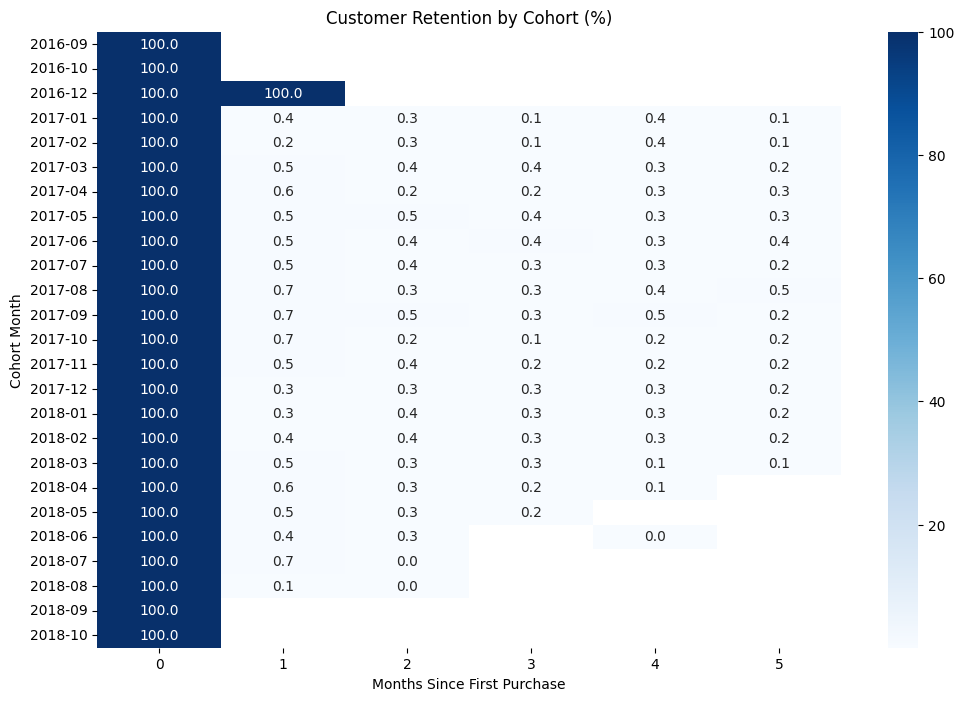

In [10]:
# Get cohort sizes (month 0 = size of that cohort)
cohort_sizes = cohort_pivot.iloc[:, 0]

# Divide every column by the cohort size to get % retention
retention = cohort_pivot.divide(cohort_sizes, axis=0) * 100

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(retention.iloc[:, :6], annot=True, fmt='.1f', cmap='Blues')
plt.title('Customer Retention by Cohort (%)')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.show()

Key Finding: Voucher-based orders show significantly lower average order value
(₹65.70 vs ₹163.32, p<0.001) compared to credit card orders. Cohort analysis
shows retention drops below 1% after month 1 for nearly all cohorts, indicating
Olist customers are largely one-time buyers. This suggests promotional vouchers
may attract deal-seeking customers rather than building long-term loyalty.